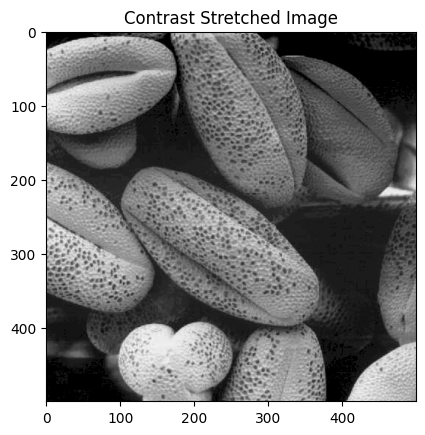

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = r"/content/drive/MyDrive/Sample images/tissues.tif"
img = cv2.imread(image_path, 0)
if img is None:
    print(f"Error: Could not load image from {image_path}. Please check the file path and ensure it exists.")
else:
    img = img.astype(np.float32)

    # Knee points
    r1, r2 = 60, 180
    s1, s2 = 30, 220

    out = np.zeros_like(img)

    mask1 = img <= r1
    mask2 = (img > r1) & (img <= r2)
    mask3 = img > r2

    out[mask1] = (s1/r1) * img[mask1]
    out[mask2] = ((s2-s1)/(r2-r1))*(img[mask2]-r1)+s1
    out[mask3] = ((255-s2)/(255-r2))*(img[mask3]-r2)+s2

    out = np.uint8(out)

    plt.imshow(out, cmap='gray')
    plt.title("Contrast Stretched Image")
    plt.show()

### Understanding Contrast Stretching with a Lookup Table (LUT)

For transformations like contrast stretching, a **Lookup Table (LUT)** is a very efficient and often simpler method for beginners to grasp. Instead of applying complex calculations to every single pixel in the image, a LUT works by:

1.  **Pre-calculating Mappings**: It creates an array (the LUT) that holds 256 entries. Each index `i` in this array corresponds to an original pixel intensity (0-255), and the value at `lut[i]` stores what that new pixel intensity should be after stretching.
2.  **Applying the Table**: Once the LUT is built, it's applied to the entire image. For each pixel in the image, its original intensity is used as an index into the LUT, and the corresponding LUT value becomes the new pixel intensity. This is extremely fast because it replaces calculations with simple lookups.

This approach makes the main part of your image processing loop much cleaner because the stretching logic is encapsulated in a function that builds the LUT.

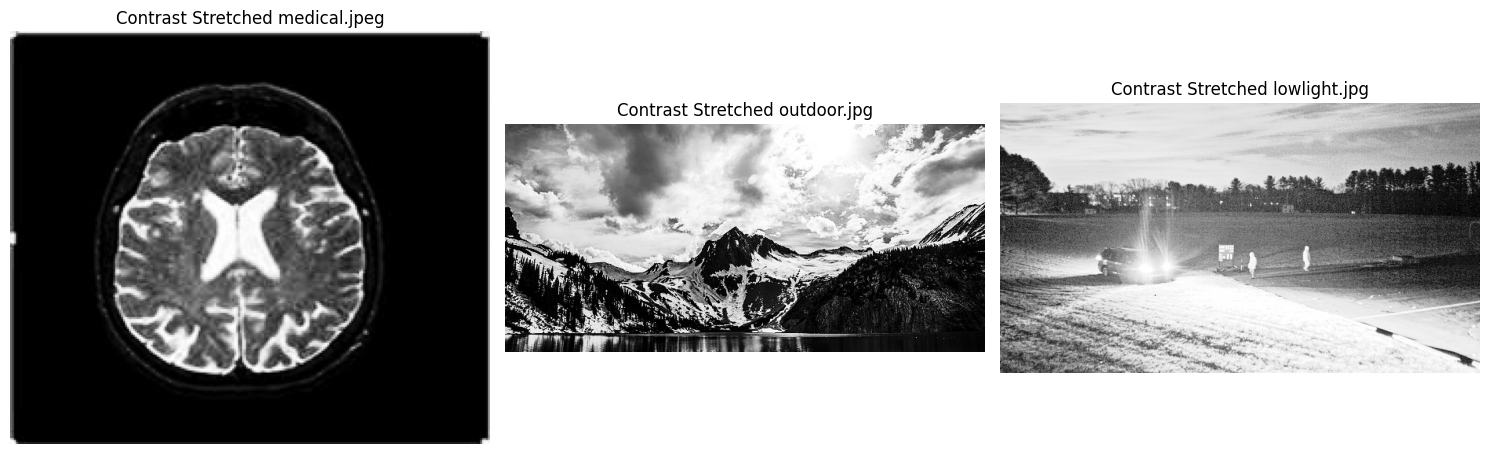

In [ ]:
import os
import matplotlib.pyplot as plt


base_path = "/content/drive/MyDrive/Sample images/"
image_filenames = ["medical.jpeg", "outdoor.jpg", "lowlight.jpg"]
images_to_process = [os.path.join(base_path, name) for name in image_filenames]

plt.figure(figsize=(15, 5))

for i, image_path in enumerate(images_to_process):
    img = cv2.imread(image_path, 0)
    if img is None:
        print(f"Error: Could not load image from {image_path}. Please check the file path and ensure it exists.")
        continue

    out = apply_contrast_stretch_lut(img, r1, s1, r2, s2)

    plt.subplot(1, len(image_filenames), i + 1)
    plt.imshow(out, cmap='gray')
    plt.title(f"Contrast Stretched {image_filenames[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

/tmp/ipython-input-2768686451.py:8: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.subplot(223), plt.hist(out.ravel(),256,[0,256])
/tmp/ipython-input-2768686451.py:9: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.subplot(224), plt.hist(he.ravel(),256,[0,256])


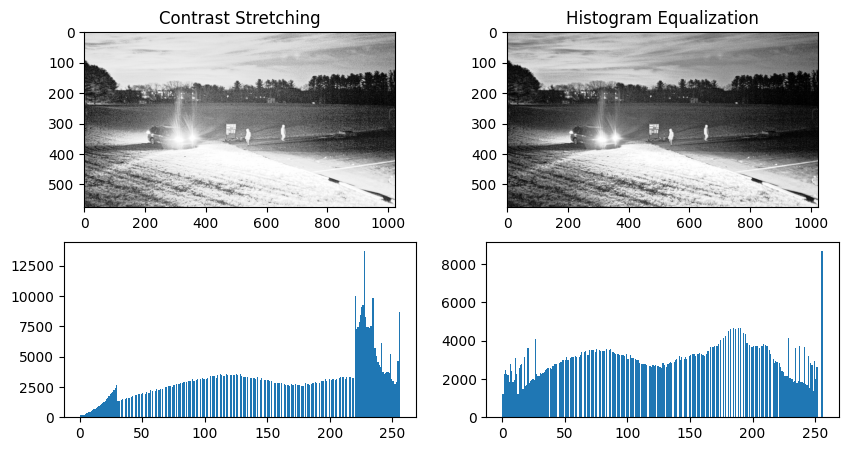

In [ ]:
he = cv2.equalizeHist(img.astype(np.uint8))

plt.figure(figsize=(10,5))

plt.subplot(221), plt.imshow(out, cmap='gray'), plt.title("Contrast Stretching")
plt.subplot(222), plt.imshow(he, cmap='gray'), plt.title("Histogram Equalization")

plt.subplot(223), plt.hist(out.ravel(),256,[0,256])
plt.subplot(224), plt.hist(he.ravel(),256,[0,256])

plt.show()
